# Experiment 3: Cross-Entropy Delta vs Diffusion Stage
Evaluates SAEs (k=50) from AwesomeInterpretability for layers L1, L10, L23 across early/middle/late diffusion stages.

In [ ]:
# Install dependencies
!pip install transformers==4.47.1 huggingface_hub hf_transfer datasets wandb matplotlib pandas tqdm nnsight==0.3.7

In [ ]:
# Clone the repo (no pip install . to avoid torch downgrade)
!git clone https://github.com/jds8/SAE4DLM-CE.git
%cd SAE4DLM-CE/train_dlm_sae

Cloning into 'SAE4DLM-CE'...
remote: Enumerating objects: 347, done.
remote: Counting objects: 100% (99/99), done.
remote: Compressing objects: 100% (77/77), done.
remote: Total 347 (delta 52), reused 53 (delta 22), pack-reused 248 (from 1)
Receiving objects: 100% (347/347), 1.19 MiB | 22.49 MiB/s, done.
Resolving deltas: 100% (133/133), done.
/content/SAE4DLM-CE/train_dlm_sae/SAE4DLM-CE/train_dlm_sae


In [ ]:
import os
import sys
import json
import csv

os.environ['HF_HUB_ENABLE_HF_TRANSFER'] = '1'
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
# Pass PYTHONPATH to subprocesses so dictionary_learning is importable
os.environ['PYTHONPATH'] = '/content/SAE4DLM-CE/train_dlm_sae'

import torch
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Torch version: {torch.__version__}")

GPU available: True
GPU: NVIDIA A100-SXM4-40GB
Torch version: 2.10.0+cu128


In [ ]:
# ====================== Config ======================

MODEL_NAME = 'Dream-org/Dream-v0-Base-7B'
HF_REPO_ID = 'AwesomeInterpretability/dlm-mask-topk-sae'
SAE_ROOT = 'saes'
DEVICE = 'cuda:0'
TOKEN_BUDGET = 1_000  # Decreased to speed up evaluation

LAYERS = [1, 10, 23]
TRAINER = 'trainer_0'  # k=50

STAGES = {
    'late':   {'t_min': 0.05, 't_max': 0.20},
    'middle': {'t_min': 0.20, 't_max': 0.35},
    'early':  {'t_min': 0.35, 't_max': 0.50},
}

OUTPUT_CSV = 'exp3_results.csv'

def sae_path(layer):
    return os.path.join(
        SAE_ROOT,
        'saes_mask_Dream-org_Dream-v0-Base-7B_top_k',
        f'resid_post_layer_{layer}',
        TRAINER,
    )


In [ ]:
# Download SAEs (trainer_0 / k=50) for L1, L10, L23
from huggingface_hub import hf_hub_download

for layer in LAYERS:
    for filename in ['ae.pt', 'config.json']:
        remote_path = (
            f'saes_mask_Dream-org_Dream-v0-Base-7B_top_k/'
            f'resid_post_layer_{layer}/{TRAINER}/{filename}'
        )
        local_file = os.path.join(sae_path(layer), filename)
        if os.path.exists(local_file):
            print(f'[Skip] {local_file}')
            continue
        print(f'[Download] {remote_path}')
        hf_hub_download(repo_id=HF_REPO_ID, filename=remote_path, local_dir=SAE_ROOT)

print('Done downloading SAEs.')

[Download] saes_mask_Dream-org_Dream-v0-Base-7B_top_k/resid_post_layer_1/trainer_0/ae.pt


saes_mask_Dream-org_Dream-v0-Base-7B_top(…):   0%|          | 0.00/470M [00:00<?, ?B/s]

[Download] saes_mask_Dream-org_Dream-v0-Base-7B_top_k/resid_post_layer_1/trainer_0/config.json


config.json:   0%|          | 0.00/952 [00:00<?, ?B/s]

[Download] saes_mask_Dream-org_Dream-v0-Base-7B_top_k/resid_post_layer_10/trainer_0/ae.pt


...

[Download] saes_mask_Dream-org_Dream-v0-Base-7B_top_k/resid_post_layer_23/trainer_0/ae.pt


saes_mask_Dream-org_Dream-v0-Base-7B_top(…):   0%|          | 0.00/470M [00:00<?, ?B/s]

[Download] saes_mask_Dream-org_Dream-v0-Base-7B_top_k/resid_post_layer_23/trainer_0/config.json


config.json:   0%|          | 0.00/955 [00:00<?, ?B/s]

Done downloading SAEs.


In [ ]:
# Run eval for each layer x stage
import subprocess

results = []

for layer in LAYERS:
    ae_root = sae_path(layer)
    assert os.path.isdir(ae_root), f'SAE path not found: {ae_root}'

    for stage_name, stage_range in STAGES.items():
        t_min = stage_range['t_min']
        t_max = stage_range['t_max']

        print(f'\n[Eval] layer={layer} stage={stage_name} t=[{t_min},{t_max}]', flush=True)

        cmd = [
            'python', '-u', 'eval_sae/eval_delta_dlm_loss.py',
            '--model_name', MODEL_NAME,
            '--ae_root', ae_root,
            '--device', DEVICE,
            '--token_budget', str(TOKEN_BUDGET),
            '--t_min', str(t_min),
            '--t_max', str(t_max),
        ]

        ret = subprocess.run(cmd)
        if ret.returncode != 0:
            print(f'[Error] Eval subprocess returned rc={ret.returncode}. Stopping.')
            break

        mask_path = os.path.join(ae_root, 'delta_lm_loss(mask).json')
        unmask_path = os.path.join(ae_root, 'delta_lm_loss(unmask).json')

        if not os.path.exists(mask_path):
            print(f'[Error] Output file not found: {mask_path}')
            print('[Hint] Check output above for [Eval] Failed messages.')
            break

        with open(mask_path) as f:
            mask_data = json.load(f)
        with open(unmask_path) as f:
            unmask_data = json.load(f)

        delta_mask = mask_data['delta_lm_loss(mask)']
        delta_unmask = unmask_data['delta_lm_loss(unmask)']

        results.append({
            'layer': layer,
            'stage': stage_name,
            't_min': t_min,
            't_max': t_max,
            'delta_lm_loss_mask': delta_mask,
            'delta_lm_loss_unmask': delta_unmask,
        })
        print(f'  delta_lm_loss(mask)={delta_mask:.6f}  delta_lm_loss(unmask)={delta_unmask:.6f}')

if results:
    fieldnames = ['layer', 'stage', 't_min', 't_max', 'delta_lm_loss_mask', 'delta_lm_loss_unmask']
    with open(OUTPUT_CSV, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(results)
    print(f'\n[Done] Results saved to {OUTPUT_CSV}')
else:
    print('[Warn] No results collected.')


[Eval] layer=1 stage=late t=[0.05,0.2]
  delta_lm_loss(mask)=-7.010955  delta_lm_loss(unmask)=-7.570732

[Eval] layer=1 stage=middle t=[0.2,0.35]
  delta_lm_loss(mask)=-3.717425  delta_lm_loss(unmask)=-8.517784

[Eval] layer=1 stage=early t=[0.35,0.5]
  delta_lm_loss(mask)=-2.525277  delta_lm_loss(unmask)=-11.176277

[Eval] layer=10 stage=late t=[0.05,0.2]
  delta_lm_loss(mask)=8.147716  delta_lm_loss(unmask)=-3.946467

[Eval] layer=10 stage=middle t=[0.2,0.35]
  delta_lm_loss(mask)=-1.419885  delta_lm_loss(unmask)=-5.396042

[Eval] layer=10 stage=early t=[0.35,0.5]
  delta_lm_loss(mask)=-1.766454  delta_lm_loss(unmask)=-7.251232

[Eval] layer=23 stage=late t=[0.05,0.2]
  delta_lm_loss(mask)=2.062500  delta_lm_loss(unmask)=-3.117915

[Eval] layer=23 stage=middle t=[0.2,0.35]
  delta_lm_loss(mask)=0.108567  delta_lm_loss(unmask)=-3.613050

[Eval] layer=23 stage=early t=[0.35,0.5]
  delta_lm_loss(mask)=-0.043449  delta_lm_loss(unmask)=-4.873096

[Done] Results saved to exp3_results.csv


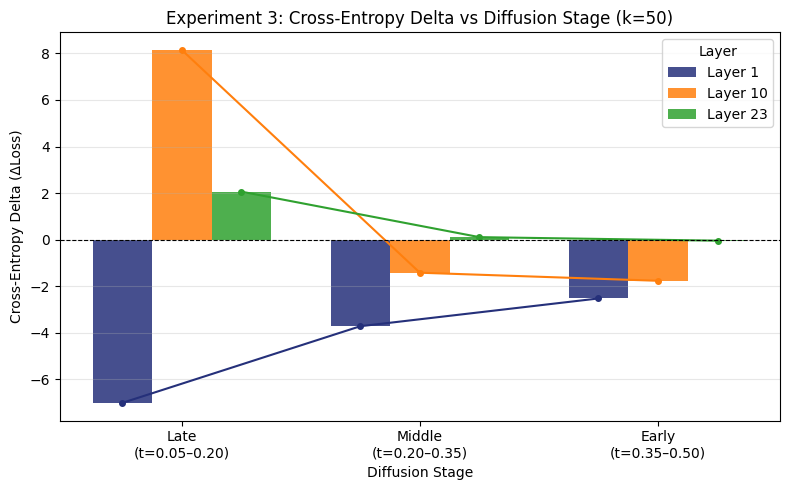

Plot saved to exp3_plot.png


In [ ]:
# Plot results
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv(OUTPUT_CSV)

STAGE_ORDER = ['late', 'middle', 'early']
STAGE_LABELS = {
    'late':   'Late\n(t=0.05–0.20)',
    'middle': 'Middle\n(t=0.20–0.35)',
    'early':  'Early\n(t=0.35–0.50)',
}
LAYER_COLORS = {1: '#25307A', 10: '#FF7F0D', 23: '#2FA12F'}

layers = sorted(df['layer'].unique())
x = np.arange(len(STAGE_ORDER))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 5))

for i, layer in enumerate(layers):
    layer_df = df[df['layer'] == layer].set_index('stage')
    values = [layer_df.loc[s, 'delta_lm_loss_mask'] if s in layer_df.index else float('nan')
              for s in STAGE_ORDER]
    offset = (i - len(layers) / 2 + 0.5) * width
    color = LAYER_COLORS.get(layer)
    ax.bar(x + offset, values, width, label=f'Layer {layer}', color=color, alpha=0.85)
    ax.plot(x + offset, values, color=color, marker='o', linewidth=1.5, markersize=4)

ax.set_xticks(x)
ax.set_xticklabels([STAGE_LABELS[s] for s in STAGE_ORDER])
ax.set_xlabel('Diffusion Stage')
ax.set_ylabel('Cross-Entropy Delta (ΔLoss)')
ax.set_title('Experiment 3: Cross-Entropy Delta vs Diffusion Stage (k=50)')
ax.legend(title='Layer')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig('exp3_plot.png', dpi=150)
plt.show()
print('Plot saved to exp3_plot.png')